# Data Initialization


In [263]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

raw_df = pd.read_csv('weekly_player_stats_offense.csv')

In [264]:
# initial values for labels of features to be used or excluded by model
categorical_features = set([])
real_val_features = set([])
features_dropped = set([]) # remove from lists of kept features
target_labels = set(['fantasy_points_ppr'])


#print(target_labels)
#print("Categorical Features: ", categorical_features)
#print("Numerical Features: ", real_val_features)

In [265]:
for col in raw_df.columns :
    if pd.api.types.is_numeric_dtype(raw_df[col]) :
        real_val_features.add(col)
    else :
        categorical_features.add(col)

#print(categorical_features)
#print(real_val_features)

In [266]:
# ensure target or potential target labels are dropped from model input df
for label in raw_df :
    label = str(label)
    if 'fantasy' in label :
        features_dropped.add(label)


for feature in features_dropped :
    if feature in real_val_features :
        real_val_features.remove(feature)
    elif feature in categorical_features :
        categorical_features.remove(feature)

#print(features_dropped)


In [267]:
# set fantasy points as targets 
# drop irrelevant / categorical features 
# condense samples to one per player - seasonal weekly average 
# make training-validation split 
# encode / normalize kept features 
# train / validate model 
# Remove features that have minimal impact on model performance 
# whatever the fuck else

# Categorical Stats
# position

# Numerical Stats
# week
# season
# passing_yards
# receiving_yards
# rushing_yards
# rush_touchdown
# pass_touchdown
# fumble_lost
# receptions
# interception

# Logically, we split the fantasy point stats between test and training and compare them against our model
# Target = fantasy_points_ppr

# plot each categorical feature and numerical feature
# find and fill holes or remove if missing too much data

# create test dataframe
# test_df = pd.concat(raw_df[catgeorical] , raw_df[real_value])

# ohe categorical features
# normalize numerical features

# train test split
	# split based on avverge fantasy points ppr? or some other metric ? 

# stick into a model - xgboost / random forest / linear regression

# graph model perofrmances, start selecting features based on importance, correlation, etc to combine or remove 

#plt.figure(dpi=500)
#sns.heatmap(position_filtered_df.isnull() , cbar=False , cmap='viridis')
#plt.ylabel('Samples')
#plt.xlabel('Features')

#plt.show()

In [268]:
# list of all features with missing 

temp = raw_df.drop(features_dropped, axis=1)
missing_values = set([])
for label in temp :
    label = str(label)
    if temp[label].isnull().any() :
        missing_values.add(label)

print(len(missing_values))
print(len(real_val_features) + len(categorical_features))

137
381


137
393


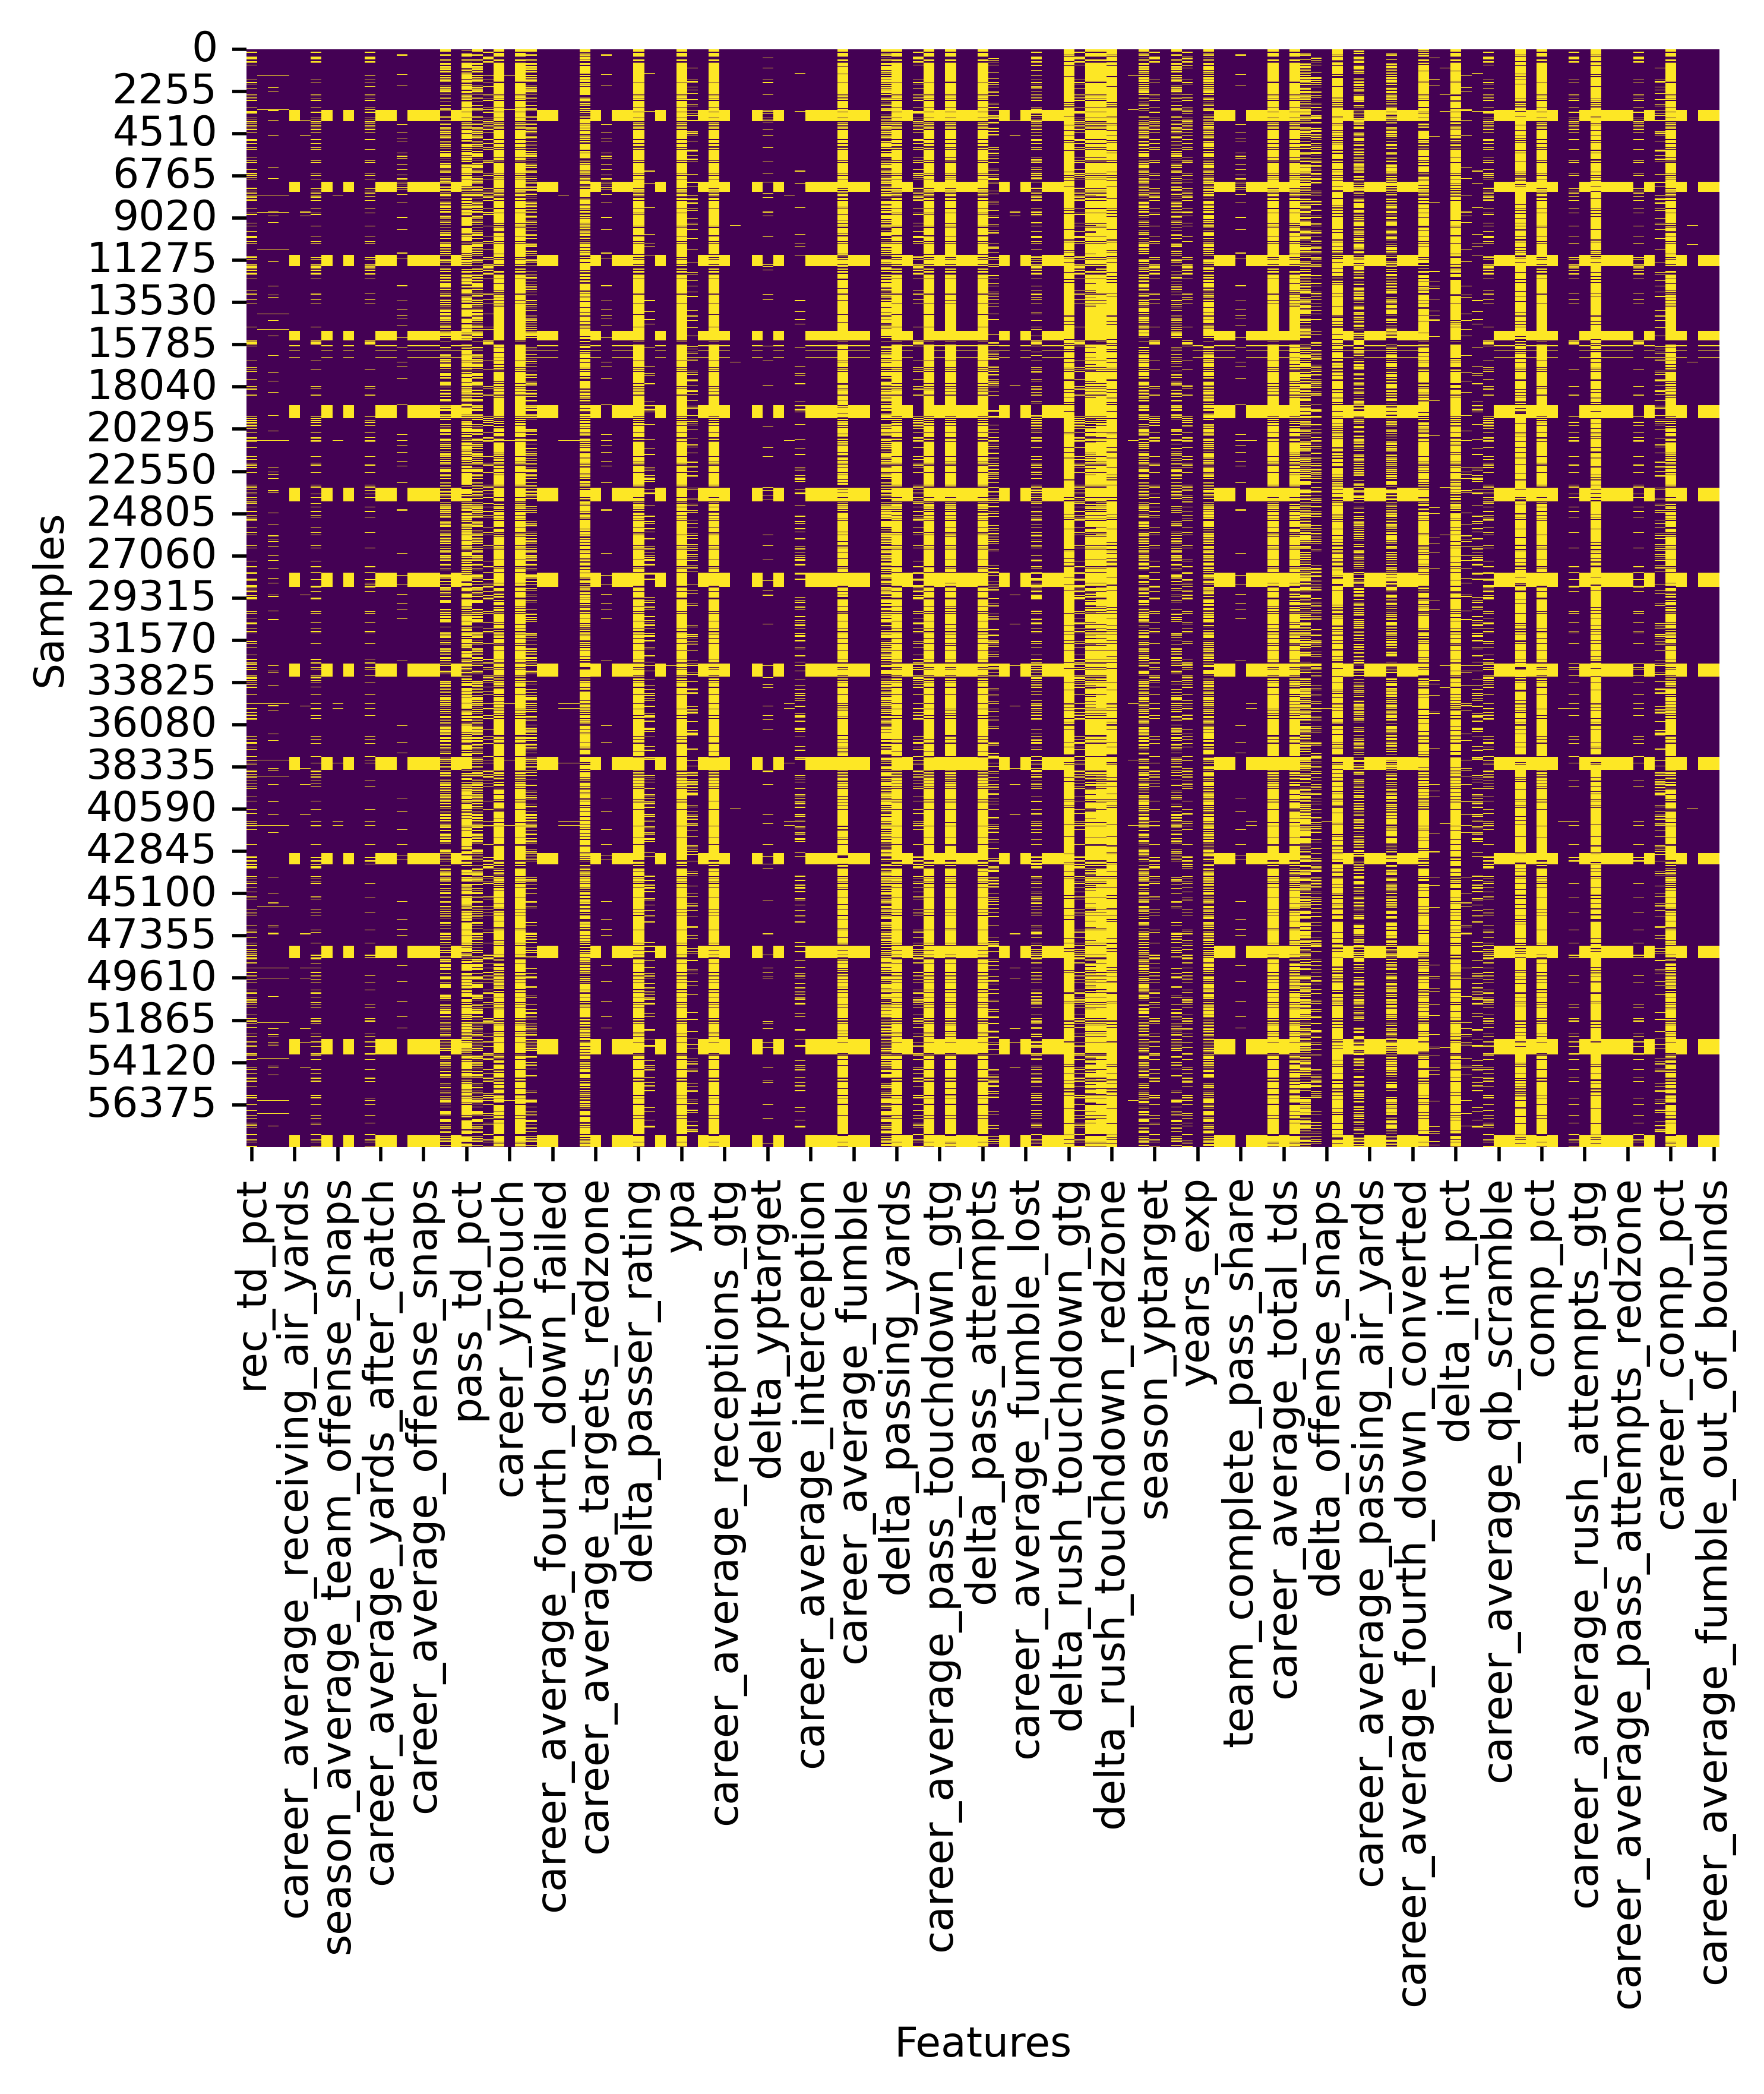

In [269]:
print(len(missing_values))
print(len(real_val_features) + len(categorical_features) + len(features_dropped))

plt.figure(dpi=500)
sns.heatmap(raw_df[list(missing_values)].isnull(), cbar=False , cmap='viridis')
plt.ylabel('Samples')
plt.xlabel('Features')
plt.show()

In [270]:
# Creating a clean dataframe by dropping features with too many missing values
missing_threshold = 0.5  # Set threshold for missing values (e.g., 30%)
missing_fraction = raw_df[list(missing_values)].isnull().mean()
potential_drop = missing_fraction[missing_fraction > missing_threshold].index
cleaned_df = raw_df.drop(columns=features_dropped)
print("Dropped features due to missing values: ", potential_drop.tolist)

# print("Cleaned DataFrame Features: ", cleaned_df.columns.tolist())

cleaned_categorical_features = [col for col in cleaned_df.columns if not pd.api.types.is_numeric_dtype(cleaned_df[col])]
cleaned_real_val_features = [col for col in cleaned_df.columns if pd.api.types.is_numeric_dtype(cleaned_df[col])]


Dropped features due to missing values:  <bound method IndexOpsMixin.tolist of Index(['pass_td_pct', 'career_ypa', 'season_ypa',
       'delta_rush_attempts_redzone', 'delta_passer_rating', 'ypa',
       'delta_incomplete_pass', 'delta_pass_td_pct', 'ypc',
       'delta_passing_yards', 'delta_complete_pass', 'season_comp_pct',
       'delta_pass_attempts', 'delta_rush_touchdown_gtg', 'career_int_pct',
       'season_int_pct', 'delta_rush_touchdown_redzone', 'rush_td_pct',
       'season_pass_touchdown_pct', 'career_pass_touchdown_pct',
       'delta_td_pct', 'delta_rush_td_pct', 'delta_total_tds', 'int_pct',
       'delta_int_pct', 'delta_rush_attempts_gtg', 'comp_pct',
       'delta_rush_touchdown', 'career_comp_pct'],
      dtype='object')>


In [271]:

# Print the heatmap of the cleaned dataframe numerical features
#plt.figure(dpi=500)
#sns.heatmap(cleaned_df[cleaned_real_val_features].isnull() , cbar=False , cmap='viridis')
#plt.ylabel('Samples')
#plt.xlabel('Features')
#plt.show()
